<a href="https://colab.research.google.com/github/nehanourin333-cpu/ML-LAB/blob/main/LOGISTIC_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_curve,roc_auc_score

In [5]:
np.random.seed(42)
sns.set_theme(style="whitegrid")
data=load_breast_cancer()
x = pd.DataFrame(data.data,columns=data.feature_names)
y = data.target
print(f"dataset shape: {x.shape}")
print(f"class distribution: {np.bincount(y)} (0: malignant,1: Begin )")

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("preprocessing complete:")

dataset shape: (569, 30)
class distribution: [212 357] (0: malignant,1: Begin )
preprocessing complete:


In [13]:
mle_model =LogisticRegression(penalty=None,max_iter=10000)
mle_model.fit(x_train,y_train)
map_l2_model = LogisticRegression(penalty="l2",C=1.0,solver='lbfgs',max_iter=10000)
map_l2_model.fit(x_train,y_train)
map_l1_model=LogisticRegression(penalty='l1',solver='saga',C=1.0,max_iter=10000)
map_l1_model.fit(x_train,y_train)
weights_df = pd.DataFrame({
    'Feature': ['Intercept'] + list(data.feature_names),
    'MLE' : np.insert(mle_model.coef_[0],0,mle_model.intercept_[0]),
    'MAP_L2(Gaussian)' : np.insert(map_l2_model.coef_[0],0,map_l2_model.intercept_[0]),
    'MAP_L1(Laplace)' : np.insert(map_l1_model.coef_[0],0,map_l1_model.intercept_[0])
})
print(weights_df)

                    Feature         MLE  MAP_L2(Gaussian)  MAP_L1(Laplace)
0                 Intercept  -63.532600          0.445585         0.299321
1               mean radius    9.433096         -0.431904         0.000000
2              mean texture  -16.986388         -0.387326         0.000000
3            mean perimeter   40.020926         -0.393432         0.000000
4                 mean area   10.890150         -0.465210         0.000000
5           mean smoothness    5.033443         -0.071667         0.000000
6          mean compactness  274.940098          0.540164         0.000000
7            mean concavity -134.838158         -0.801458         0.000000
8       mean concave points -266.184736         -1.119804        -2.195998
9             mean symmetry   40.996505          0.236119         0.053600
10   mean fractal dimension -168.017946          0.075921         0.000000
11             radius error -259.639462         -1.268178        -2.447947
12            texture err

In [16]:
def evaluate_model(model, x, y, name):
    preds = model.predict(x)
    probs = model.predict_proba(x)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y, preds),
        'Precision': precision_score(y, preds),
        'Recall': recall_score(y, preds),
        'F1-Score': f1_score(y, preds),
        'AUC-ROC': roc_auc_score(y, probs)
    }
results = [
    evaluate_model(mle_model, x_test, y_test, 'MLE(NO Regularization)'),
    evaluate_model(map_l2_model, x_test, y_test, 'MAP (L2 Regularization)'),
    evaluate_model(map_l1_model, x_test, y_test, 'MAP (L1 Regularization)')
]

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,MLE(NO Regularization),0.938596,0.984848,0.915493,0.948905,0.981330
1,MAP (L2 Regularization),0.973684,0.972222,0.985915,0.979021,0.997380
2,MAP (L1 Regularization),0.964912,0.971831,0.971831,0.971831,0.996725


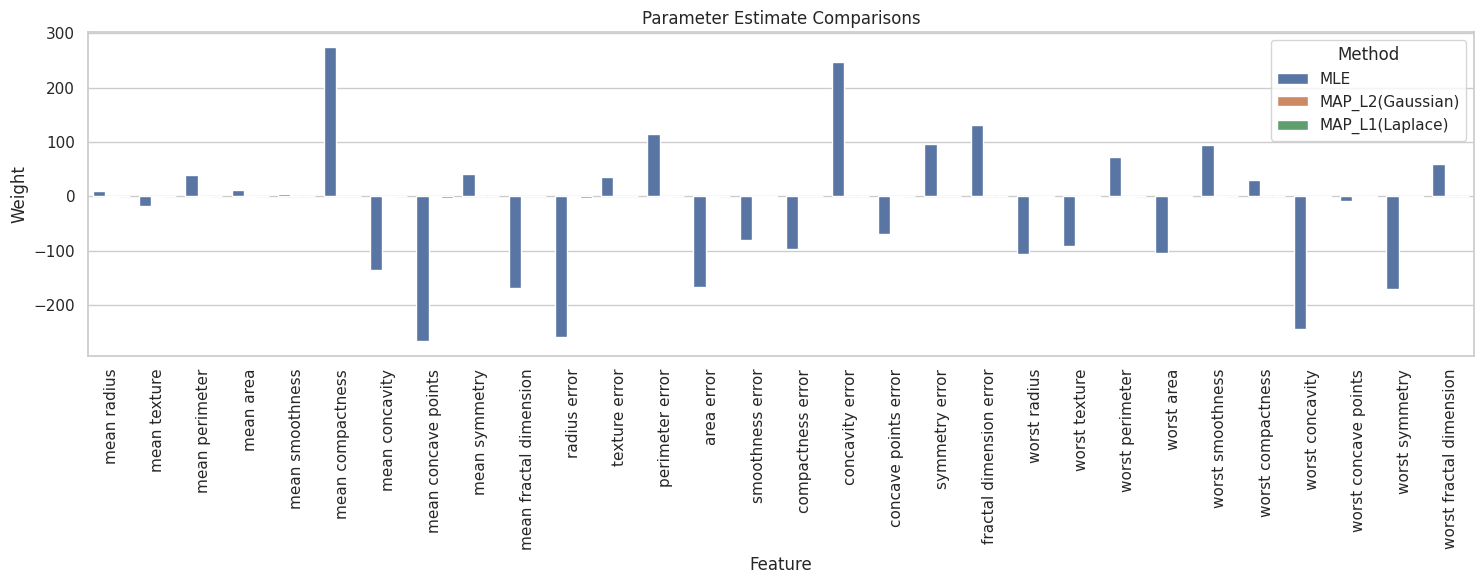

In [19]:
plt.figure(figsize=(15,6))
melted_w=weights_df.melt(id_vars='Feature',value_vars=['MLE','MAP_L2(Gaussian)','MAP_L1(Laplace)'],
                         var_name='Method',value_name='Weight')
sns.barplot(data=melted_w[melted_w['Feature'] != 'Intercept'], x='Feature',y='Weight',hue='Method')
plt.xticks(rotation=90)
plt.title('Parameter Estimate Comparisons')
plt.tight_layout()
plt.show()